# Лабораторная работа №5 — Ансамбли моделей (часть 1)
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** изучить методы ансамблирования: бэггинг, случайный лес, AdaBoost, градиентный бустинг.


## 0. Описание датасета — Titanic
891 пассажир · 7 признаков · бинарная классификация (survived: 0/1).

### Ансамбли: идея
| Метод | Принцип | Параллельно? |
|---|---|---|
| Bagging | усреднение независимых деревьев на bootstrap-выборках | да |
| Random Forest | Bagging + случайный выбор признаков в каждом узле | да |
| AdaBoost | последовательное обучение слабых классификаторов с весами | нет |
| GradientBoosting | последовательное исправление остатков через градиентный спуск | нет |


In [1]:
%matplotlib inline
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score, f1_score

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

raw = sns.load_dataset('titanic')
FEATURES = ['pclass','sex','age','sibsp','parch','fare','embarked']
X = raw[FEATURES]; y = raw['survived']
print('Размер:', X.shape)


Размер: (891, 7)


In [2]:
num_cols = ['pclass','age','sibsp','parch','fare']
cat_cols = ['sex','embarked']

prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore',
                                            sparse_output=False))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Train: 668 | Test: 223


## 1. Обучение четырёх ансамблей


In [3]:
models = {
    'Bagging(DT)':        BaggingClassifier(
                              estimator=DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
                              n_estimators=200, random_state=RANDOM_STATE),
    'RandomForest':       RandomForestClassifier(n_estimators=300, max_depth=6,
                                                  random_state=RANDOM_STATE),
    'AdaBoost':           AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=200,
                                                       random_state=RANDOM_STATE),
}

rows = []; rf_pipe = None
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({'Модель': name,
                 'Accuracy': round(accuracy_score(y_test, pred), 4),
                 'F1':       round(f1_score(y_test, pred), 4)})
    if name == 'RandomForest': rf_pipe = pipe

res = pd.DataFrame(rows).sort_values('F1', ascending=False)
display(res)
res.to_json(ART / 'metrics.json', orient='records', force_ascii=False, indent=2)


,Модель,Accuracy,F1
2,AdaBoost,0.7892,0.7283
3,GradientBoosting,0.7937,0.7089
1,RandomForest,0.7892,0.6887
0,Bagging(DT),0.7982,0.6809


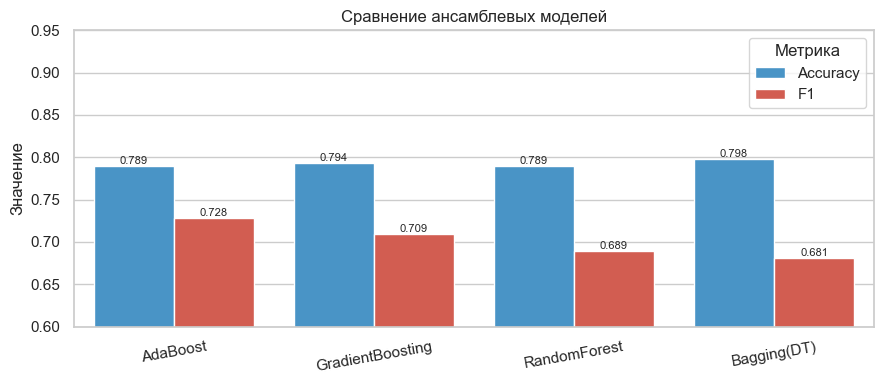

In [4]:
fig, ax = plt.subplots(figsize=(9,4))
plot_df = res.melt(id_vars='Модель', value_vars=['Accuracy','F1'],
                   var_name='Метрика', value_name='Значение')
bars = sns.barplot(data=plot_df, x='Модель', y='Значение',
                   hue='Метрика', palette=['#3498db','#e74c3c'], ax=ax)
for p in bars.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x()+p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
ax.set_ylim(0.6, 0.95); ax.set_title('Сравнение ансамблевых моделей')
ax.tick_params(axis='x', rotation=10); ax.set_xlabel('')
plt.tight_layout()
fig.savefig(ART / 'ensembles_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Важность признаков (Random Forest)
Random Forest усредняет важности из всех деревьев — это даёт более устойчивую оценку, чем одно дерево решений.


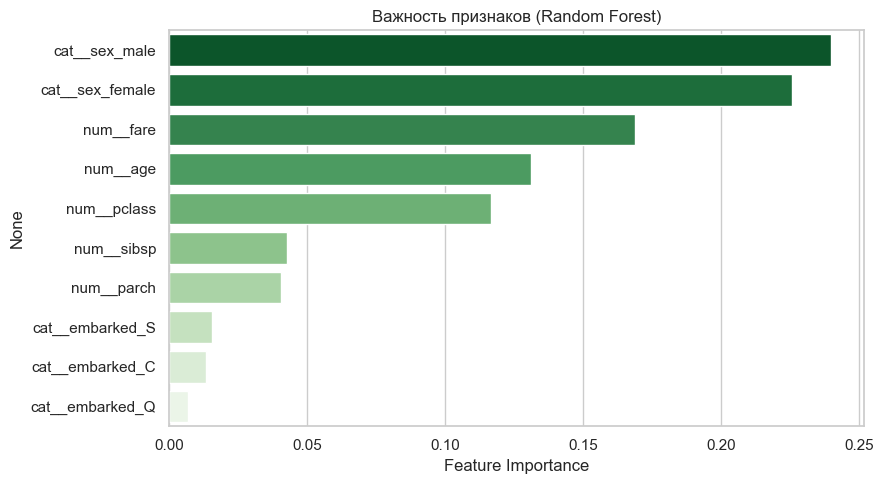

,importance
cat__sex_male,0.2397
cat__sex_female,0.2255
num__fare,0.1686
num__age,0.1311
num__pclass,0.1165
num__sibsp,0.0426
num__parch,0.0404
cat__embarked_S,0.0155
cat__embarked_C,0.0133
cat__embarked_Q,0.0067


In [5]:
feat_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_
imp = (pd.Series(importances, index=feat_names)
       .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=imp.values, y=imp.index, palette='Greens_r', ax=ax)
ax.set_title('Важность признаков (Random Forest)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
fig.savefig(ART / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
display(imp.to_frame('importance').round(4))


## Выводы
- **Bagging** снижает дисперсию одного дерева за счёт усреднения по bootstrap-выборкам.
- **Random Forest** дополнительно снижает корреляцию между деревьями через случайный выбор признаков → более стабильный результат.
- **AdaBoost** последовательно исправляет ошибки предыдущей модели через перевзвешивание объектов.
- **Gradient Boosting** строит ансамбль через градиентный спуск в пространстве функций — как правило, даёт лучшее качество ценой большего времени обучения.
- Наиболее важные признаки (Random Forest): `sex`, `fare`, `age` — совпадает с выводами лаб. 1 и 4.
